Importation des biblio nécessaire

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import OrdinalEncoder,OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
import pickle


Chargement du dataset

In [24]:
df=pd.read_csv('newdata.csv')
df

,Age,Gender,EducationLevel,ExperienceYears,PreviousCompanies,DistanceFromCompany,InterviewScore,SkillScore,PersonalityScore,RecruitmentStrategy,HiringDecision
0,26.0,male,licence,0.0,3.0,26.783828,48,78,91,1,yes
1,39.0,male,phd,12.0,3.0,25.862694,35,68,80,2,yes
2,48.0,female,licence,3.0,2.0,9.920805,20,67,13,2,no
3,34.0,male,licence,5.0,2.0,6.407751,36,27,70,3,no
4,NaN,NaN,bac,6.0,1.0,43.105343,23,52,85,2,no
...,...,...,...,...,...,...,...,...,...,...,...
1495,48.0,female,licence,3.0,4.0,9.183783,66,3,80,3,yes
1496,27.0,male,licence,10.0,3.0,14.847731,43,97,7,2,no
1497,24.0,male,bac,1.0,2.0,4.289911,31,91,58,1,yes
1498,48.0,female,licence,4.0,4.0,36.299263,9,37,44,2,yes


Dataset Information/Stat

In [25]:
df.shape

(1500, 11)

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  1494 non-null   float64
 1   Gender               1491 non-null   object 
 2   EducationLevel       1500 non-null   object 
 3   ExperienceYears      1495 non-null   float64
 4   PreviousCompanies    1495 non-null   float64
 5   DistanceFromCompany  1500 non-null   float64
 6   InterviewScore       1500 non-null   int64  
 7   SkillScore           1500 non-null   int64  
 8   PersonalityScore     1500 non-null   int64  
 9   RecruitmentStrategy  1500 non-null   int64  
 10  HiringDecision       1500 non-null   object 
dtypes: float64(4), int64(4), object(3)
memory usage: 129.0+ KB


In [27]:
df.describe()

,Age,ExperienceYears,PreviousCompanies,DistanceFromCompany,InterviewScore,SkillScore,PersonalityScore,RecruitmentStrategy
count,1494.000000,1495.000000,1495.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,35.147256,7.687625,3.006020,25.505379,50.564000,51.116000,49.387333,1.893333
std,9.256977,4.644607,1.410647,14.567151,28.626215,29.353563,29.353201,0.689642
min,20.000000,0.000000,1.000000,1.031376,0.000000,0.000000,0.000000,1.000000
25%,27.000000,4.000000,2.000000,12.838851,25.000000,25.750000,23.000000,1.000000
50%,35.000000,8.000000,3.000000,25.502239,52.000000,53.000000,49.000000,2.000000
75%,43.000000,12.000000,4.000000,37.737996,75.000000,76.000000,76.000000,2.000000
max,50.000000,15.000000,5.000000,50.992462,100.000000,100.000000,100.000000,3.000000


Nbr de valeur dans chaque colonne

In [28]:
df.nunique()

Age                      31
Gender                    2
EducationLevel            4
ExperienceYears          16
PreviousCompanies         5
DistanceFromCompany    1500
InterviewScore          101
SkillScore              101
PersonalityScore        101
RecruitmentStrategy       3
HiringDecision            2
dtype: int64

Visualisation 

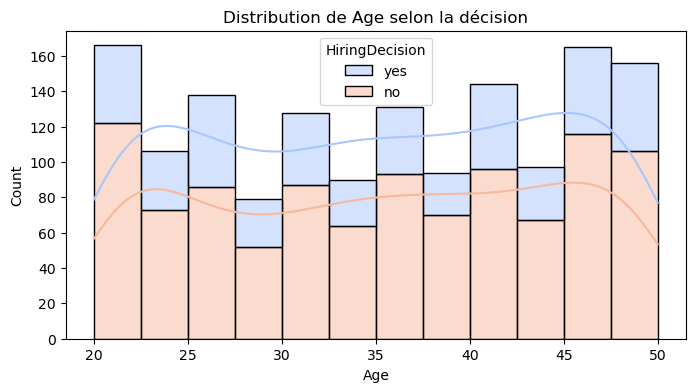

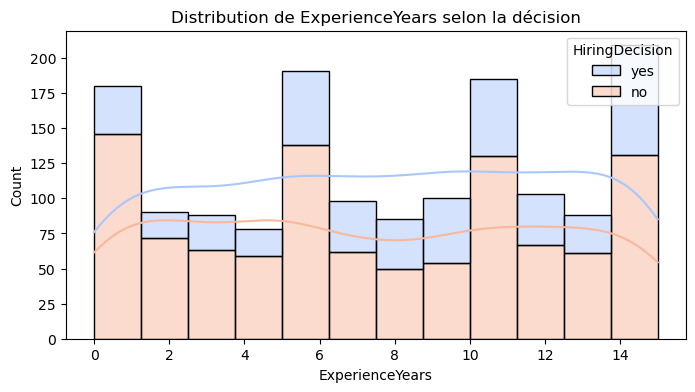

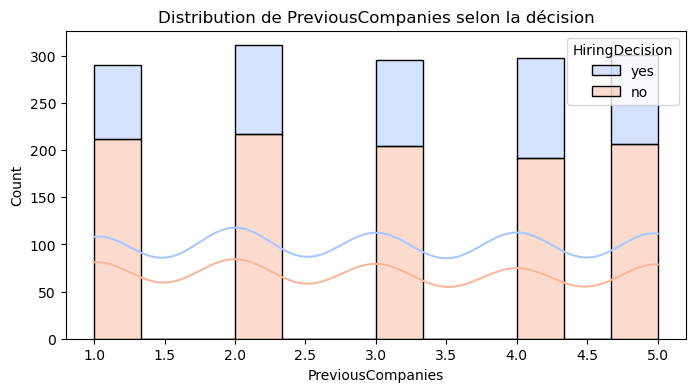

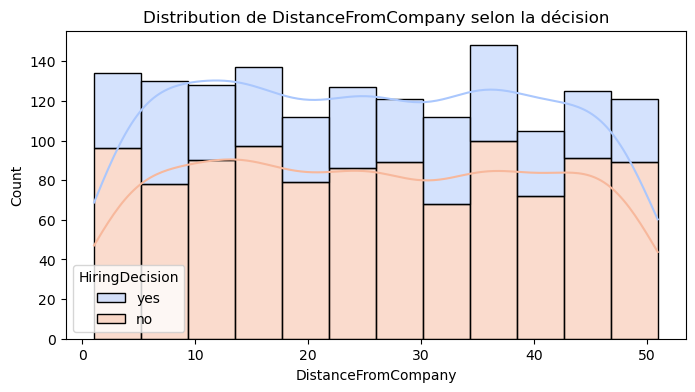

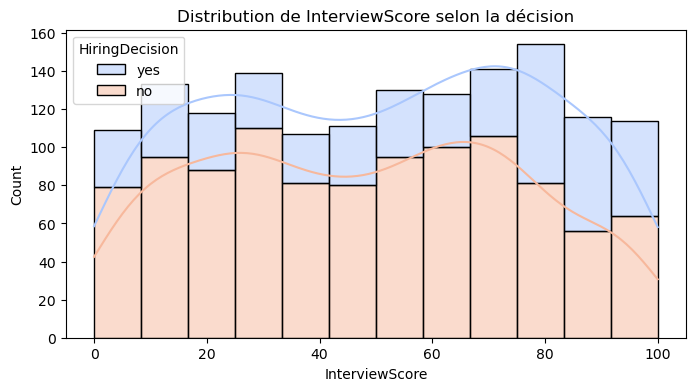

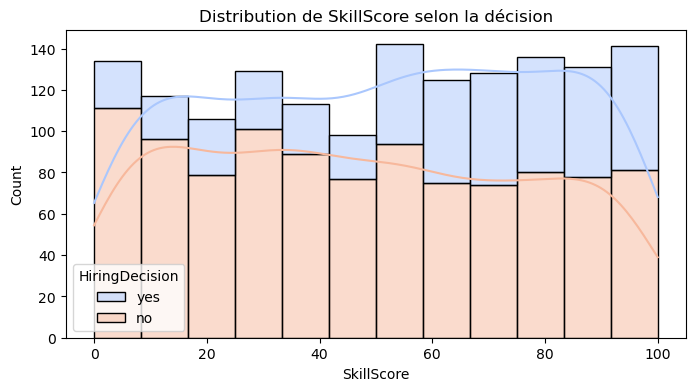

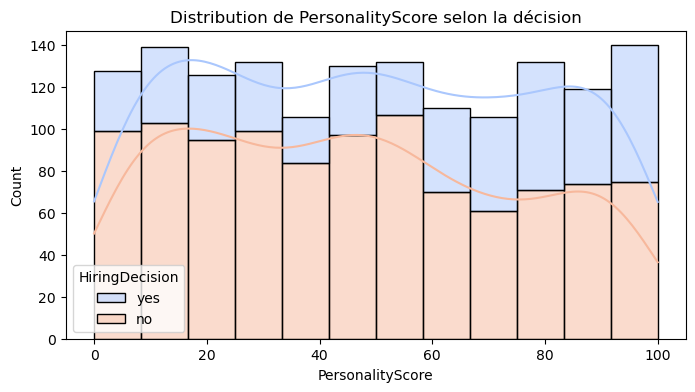

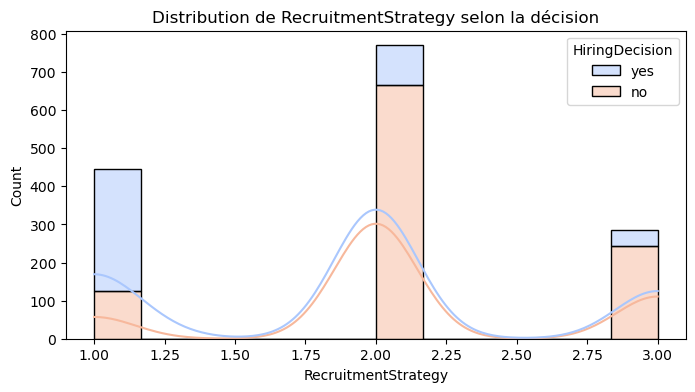

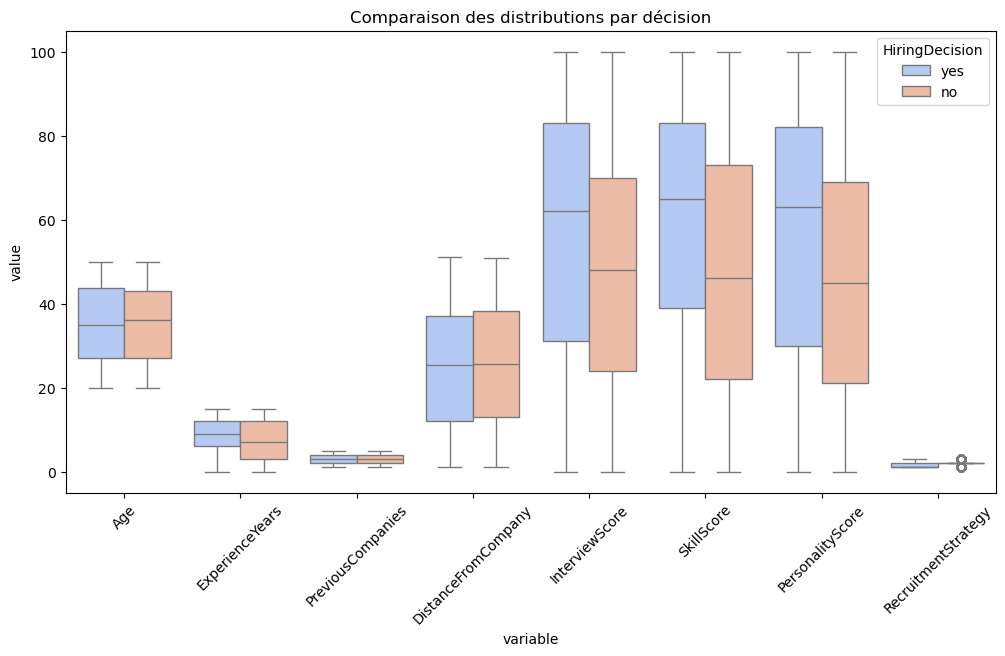

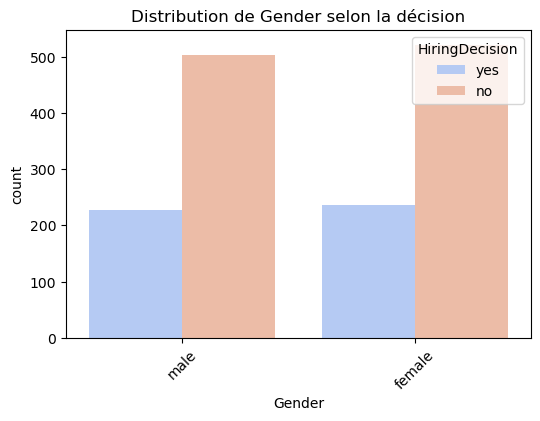

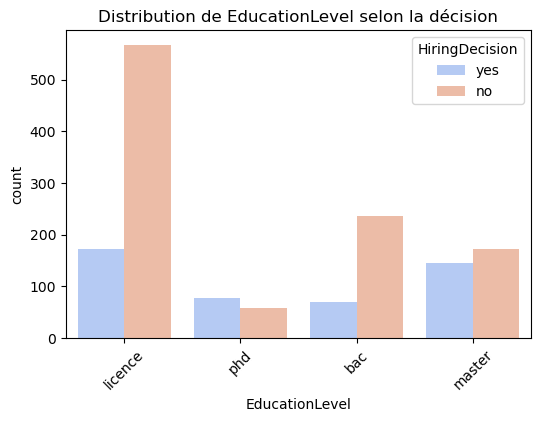

In [29]:
import seaborn as sns




numerical_cols = df.select_dtypes(include=["number"]).columns
categorical_cols = df.select_dtypes(exclude=["number"]).columns


for col in numerical_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(data=df, x=col, hue="HiringDecision", kde=True, multiple="stack", palette="coolwarm")
    plt.title(f"Distribution de {col} selon la décision")
    plt.show()


plt.figure(figsize=(12, 6))
df_melted = df.melt(id_vars=["HiringDecision"], value_vars=numerical_cols)
sns.boxplot(data=df_melted, x="variable", y="value", hue="HiringDecision", palette="coolwarm")
plt.title("Comparaison des distributions par décision")
plt.xticks(rotation=45)
plt.show()


categorical_cols = list(categorical_cols) + ["EducationLevel"] if "EducationLevel" not in categorical_cols else categorical_cols


for col in categorical_cols:
    if col != "HiringDecision":  
        plt.figure(figsize=(6, 4))
        sns.countplot(data=df, x=col, hue="HiringDecision", palette="coolwarm")
        plt.title(f"Distribution de {col} selon la décision")
        plt.xticks(rotation=45)
        plt.show()


Traitement 

Données manquantes

In [30]:
df.isnull().sum()

Age                    6
Gender                 9
EducationLevel         0
ExperienceYears        5
PreviousCompanies      5
DistanceFromCompany    0
InterviewScore         0
SkillScore             0
PersonalityScore       0
RecruitmentStrategy    0
HiringDecision         0
dtype: int64

<Axes: >

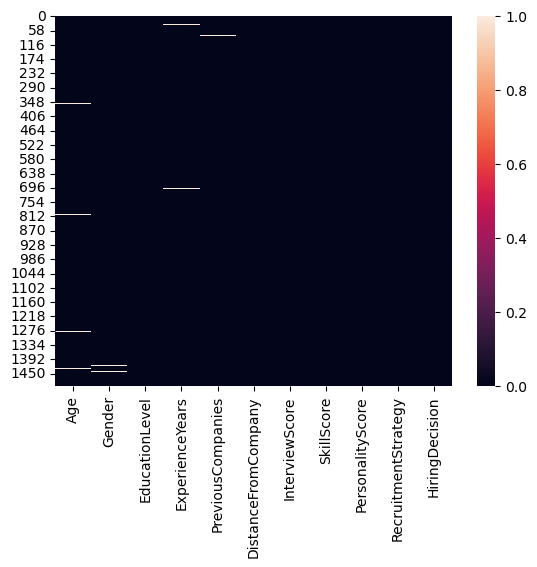

In [31]:
sns.heatmap(df.isnull())

In [32]:
categorical_col = df[['EducationLevel', 'Gender', 'HiringDecision']]
numerical_col = df.drop(columns=['EducationLevel', 'Gender', 'HiringDecision'])

print("Colonnes catégorielles :\n", categorical_col.head())
print("\nColonnes numériques :\n", numerical_col.head())


Colonnes catégorielles :
   EducationLevel  Gender HiringDecision
0        licence    male            yes
1            phd    male            yes
2        licence  female             no
3        licence    male             no
4            bac     NaN             no

Colonnes numériques :
     Age  ExperienceYears  PreviousCompanies  DistanceFromCompany  \
0  26.0              0.0                3.0            26.783828   
1  39.0             12.0                3.0            25.862694   
2  48.0              3.0                2.0             9.920805   
3  34.0              5.0                2.0             6.407751   
4   NaN              6.0                1.0            43.105343   

   InterviewScore  SkillScore  PersonalityScore  RecruitmentStrategy  
0              48          78                91                    1  
1              35          68                80                    2  
2              20          67                13                    2  
3              36

traitement des Donnée manquantes

In [33]:
for c in categorical_col:
    df[c]=df[c].fillna(df[c].mode()[0])
df


,Age,Gender,EducationLevel,ExperienceYears,PreviousCompanies,DistanceFromCompany,InterviewScore,SkillScore,PersonalityScore,RecruitmentStrategy,HiringDecision
0,26.0,male,licence,0.0,3.0,26.783828,48,78,91,1,yes
1,39.0,male,phd,12.0,3.0,25.862694,35,68,80,2,yes
2,48.0,female,licence,3.0,2.0,9.920805,20,67,13,2,no
3,34.0,male,licence,5.0,2.0,6.407751,36,27,70,3,no
4,NaN,female,bac,6.0,1.0,43.105343,23,52,85,2,no
...,...,...,...,...,...,...,...,...,...,...,...
1495,48.0,female,licence,3.0,4.0,9.183783,66,3,80,3,yes
1496,27.0,male,licence,10.0,3.0,14.847731,43,97,7,2,no
1497,24.0,male,bac,1.0,2.0,4.289911,31,91,58,1,yes
1498,48.0,female,licence,4.0,4.0,36.299263,9,37,44,2,yes


In [34]:
for n in numerical_col:
    df[n]=df[n].fillna(df[n].median())
df

,Age,Gender,EducationLevel,ExperienceYears,PreviousCompanies,DistanceFromCompany,InterviewScore,SkillScore,PersonalityScore,RecruitmentStrategy,HiringDecision
0,26.0,male,licence,0.0,3.0,26.783828,48,78,91,1,yes
1,39.0,male,phd,12.0,3.0,25.862694,35,68,80,2,yes
2,48.0,female,licence,3.0,2.0,9.920805,20,67,13,2,no
3,34.0,male,licence,5.0,2.0,6.407751,36,27,70,3,no
4,35.0,female,bac,6.0,1.0,43.105343,23,52,85,2,no
...,...,...,...,...,...,...,...,...,...,...,...
1495,48.0,female,licence,3.0,4.0,9.183783,66,3,80,3,yes
1496,27.0,male,licence,10.0,3.0,14.847731,43,97,7,2,no
1497,24.0,male,bac,1.0,2.0,4.289911,31,91,58,1,yes
1498,48.0,female,licence,4.0,4.0,36.299263,9,37,44,2,yes


In [35]:
df.isnull().sum()

Age                    0
Gender                 0
EducationLevel         0
ExperienceYears        0
PreviousCompanies      0
DistanceFromCompany    0
InterviewScore         0
SkillScore             0
PersonalityScore       0
RecruitmentStrategy    0
HiringDecision         0
dtype: int64

In [36]:
df.to_csv('dataset_traté.csv', index=False)

Transformer les colonne catégorique en Numérique

In [37]:
from sklearn.preprocessing import OrdinalEncoder

ordinal_encoder = OrdinalEncoder()
categorical_cols = ['EducationLevel', 'Gender', 'HiringDecision']
df[categorical_cols] = ordinal_encoder.fit_transform(df[categorical_cols])

print(df.head())

    Age  Gender  EducationLevel  ExperienceYears  PreviousCompanies  \
0  26.0     1.0             1.0              0.0                3.0   
1  39.0     1.0             3.0             12.0                3.0   
2  48.0     0.0             1.0              3.0                2.0   
3  34.0     1.0             1.0              5.0                2.0   
4  35.0     0.0             0.0              6.0                1.0   

   DistanceFromCompany  InterviewScore  SkillScore  PersonalityScore  \
0            26.783828              48          78                91   
1            25.862694              35          68                80   
2             9.920805              20          67                13   
3             6.407751              36          27                70   
4            43.105343              23          52                85   

   RecruitmentStrategy  HiringDecision  
0                    1             1.0  
1                    2             1.0  
2                

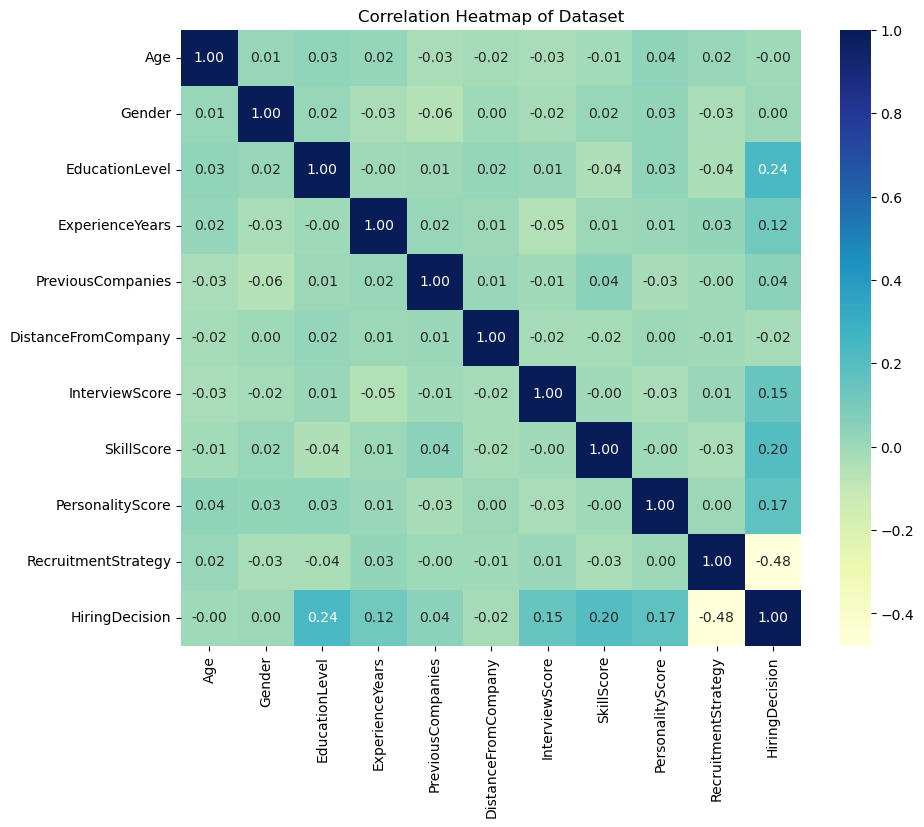

In [38]:
plt.figure(figsize = (10, 8))
sns.heatmap(df.corr(), annot = True, fmt = '0.2f', cmap = 'YlGnBu')
plt.title('Correlation Heatmap of Dataset')
plt.show()

Traitement des données abbérantes

In [39]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

aberr = ((df < lower_bound) | (df > upper_bound)).any(axis=1)

df_cleaned = df[~aberr]

print("Shape avant le Traitement des données abbérantes:", df.shape)
print("Shape après le Traitement des données abbérantes:", df_cleaned.shape)

Shape avant le Traitement des données abbérantes: (1500, 11)
Shape après le Traitement des données abbérantes: (1500, 11)


Modeles

In [40]:

models={ 
        'SVC_C_10_kernel_rbf': SVC(C=10.0, kernel='rbf'),
        'SVC_C_10_kernel_poly': SVC(C=10.0, kernel='poly', degree=3),
        'KNN_5':KNeighborsClassifier(n_neighbors=5),
        'KNN_11':KNeighborsClassifier(n_neighbors=11),
        'KNN_113':KNeighborsClassifier(n_neighbors=113),
        'LogisticRegression':LogisticRegression(max_iter=5000),
        'RandomForestClassifier':RandomForestClassifier(),
        'MLPClassifier': MLPClassifier(),
        'DecisionTreeClassifier': DecisionTreeClassifier()
}

In [41]:
def accuracy(y_pred,y_test,R=False):
    accuracy=accuracy_score(y_pred,y_test)
    if R:
        return accuracy
    else:
        print(f'Accuracy :{accuracy}')

In [42]:
df = df[['EducationLevel', 'SkillScore', 'InterviewScore','PersonalityScore', 'HiringDecision']]
X = df.drop(columns=['HiringDecision'])
y = df['HiringDecision']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [43]:
from sklearn.model_selection import cross_val_score
import pandas as pd
from tabulate import tabulate

results_list = []


for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
    results_list.append([name, scores.mean()])


results_df = pd.DataFrame(results_list, columns=["Modèle", "Précision "])

print(tabulate(results_df, headers="keys", tablefmt="pretty"))


+---+------------------------+--------------------+
|   |         Modèle         |     Précision      |
+---+------------------------+--------------------+
| 0 |  SVC_C_10_kernel_rbf   | 0.7013333333333334 |
| 1 |  SVC_C_10_kernel_poly  | 0.7366666666666666 |
| 2 |         KNN_5          | 0.6773333333333333 |
| 3 |         KNN_11         | 0.7006666666666665 |
| 4 |        KNN_113         |        0.7         |
| 5 |   LogisticRegression   |       0.738        |
| 6 | RandomForestClassifier | 0.7380000000000001 |
| 7 |     MLPClassifier      | 0.7146666666666667 |
| 8 | DecisionTreeClassifier | 0.6546666666666666 |
+---+------------------------+--------------------+


In [44]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

clf = LogisticRegression(max_iter=1000, random_state=42)

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")


Accuracy: 0.75


In [45]:
pickle.dump(clf,open('model.pkl','wb'))